# ETF 动量 + 风险平价策略研究

首次执行数据单元查询全部 `FUND_CODES`。之后只需修改标的池或策略参数，重新执行回测单元即可复用已查询的数据。

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from core.database import create_session
from research import get_data, run_strategy

2026-07-28 15:07:23 [SUCCESS] ts_api.py | <module>: 187行| Tushare Pro 初始化完成，共加载 5,871 只股票
2026-07-28 15:07:23 [ INFO  ] session.py | <module>: 10行| DolphinDB: 127.0.0.1:8848


In [2]:
FACTOR_NAMES = [
    "open",
    "high",
    "low",
    "close",
    "pre_close",
    "adj_factor",
    "vol",
]
START_DATE = np.datetime64("2020-01-01", "D")
END_DATE = np.datetime64("2026-07-26", "D")
INITIAL_CASH = 100_000.0
HISTORY_BUFFER_DAYS = 120

## 查询并缓存全部 ETF 数据

In [3]:
session = create_session()
data_profile = get_data(
    session,
    FACTOR_NAMES,
    START_DATE,
    END_DATE,
    HISTORY_BUFFER_DAYS,
)
data_profile

{'strategyMarketData': 94971, 'strategyMessage': 92343}

## 使用选定 ETF 池运行回测

修改 `CODE_NAMES` 或其他策略参数后，只需重新执行下面的单元。

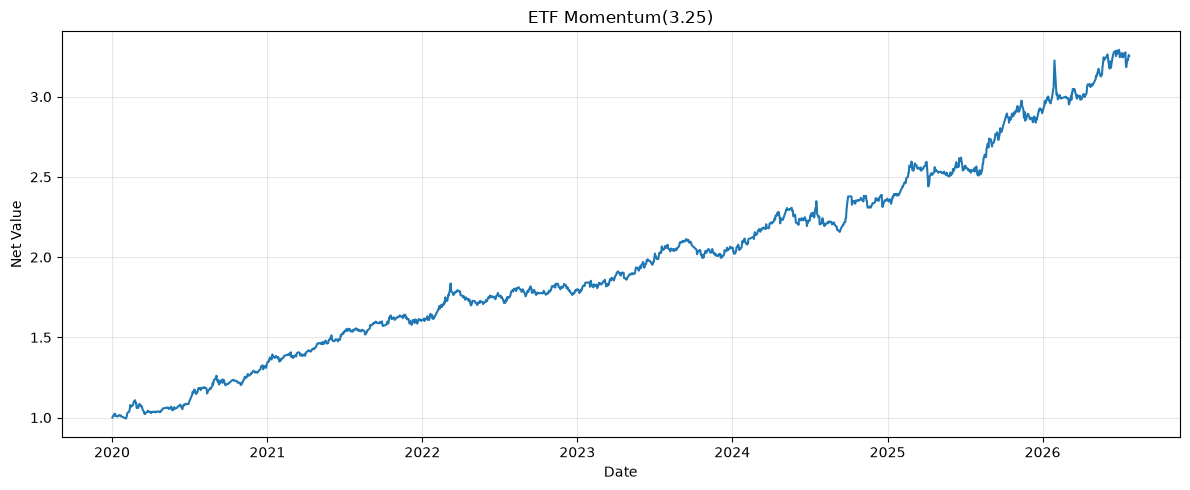

In [4]:
CODE_NAMES = [
    "518880.SH",  # 黄金
    "159980.SZ",  # 有色
    "159985.SZ",  # 豆粕
    "501018.SH",  # 原油
    "513400.SH",  # 道琼斯
    "513100.SH",  # 纳指
    "513500.SH",  # 标普500
    "513120.SH",  # 港股创新药
    "513070.SH",  # 港股消费
    "588000.SH",  # 科创50
    "159967.SZ",  # 创成长
    "512890.SH",  # 红利低波
    "513880.SH",  # 日经225
]

MOMENTUM_WINDOW = 21
SELECT_COUNT = 4
RISK_WINDOW = 20
MAX_HISTORY_ROWS = 90
TARGET_VOLATILITY = 0.09
MAX_INVESTED_RATIO = 0.99

net_value = run_strategy(
    session,
    CODE_NAMES,
    START_DATE,
    END_DATE,
    INITIAL_CASH,
    MOMENTUM_WINDOW,
    SELECT_COUNT,
    RISK_WINDOW,
    MAX_HISTORY_ROWS,
    TARGET_VOLATILITY,
    MAX_INVESTED_RATIO,
)
figure, axis = plt.subplots(figsize=(12, 5))
axis.plot(net_value.index, net_value.to_numpy())
axis.set(
    title=f"ETF Momentum({net_value.iloc[-1]:.2f})",
    xlabel="Date",
    ylabel="Net Value",
)
axis.grid(alpha=0.3)
figure.tight_layout()
plt.show()